# Data Collaboration Quickstart (Three-Layer Pipeline)

このノートブックでは `run_once` を使わず、`src/` 以下に実装された 3 層パイプライン（データ層 / 中間層 / 統合層）を直接操作して、個別解析・集中解析・各統合法の指標を算出します。


## 0. プロジェクトルートを Python Path に追加


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
print(f'Project root: {PROJECT_ROOT}')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


Project root: C:\Users\sueya\Git-Repositories\takano_labo\dca


## 1. ベース設定とログ出力の準備

単一の `base_config` から `Config` を生成し、必要に応じてパラメータを上書きするヘルパーを用意します。以降のセルはすべてこの設定を共有します。


In [12]:
import logging
from copy import deepcopy
from pprint import pprint

import numpy as np
import pandas as pd

from config.config import Config
from src.paths import OUTPUT_DIR

logger = logging.getLogger('dca.quickstart')
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter('%(levelname)s - %(message)s'))
    logger.addHandler(handler)
logger.setLevel(logging.INFO)

output_dir = OUTPUT_DIR / 'quickstart_notebook'
output_dir.mkdir(parents=True, exist_ok=True)

base_config = {
    'name': 'tutorial_mnist',
    'dataset': 'mnist',
    'y_name': 'target',
    'num_institution': 3,
    'num_institution_user': 200,
    'data_distribution': 'even',
    'num_anchor_data': 256,
    'dim_intermediate': 20,
    'dim_integrate': 20,
    'F_type': 'svd',
    'G_type': 'Imakura',
    'metrics': 'auc',
    'seed': 42,
    'visualize': True,
    'load_df_data': False,
    'load_intermediate_data': False,
    'inter_normalization': False,
    'anchor_method': 'gaussian',
    'output_path': output_dir,
    'h_model': 'mlp',
}

def make_config(**overrides) -> Config:
    cfg_dict = deepcopy(base_config)
    cfg_dict.update(overrides)
    return Config(**cfg_dict)

base_cfg = make_config()
pprint({k: getattr(base_cfg, k) for k in base_config.keys()})


{'F_type': 'svd',
 'G_type': 'Imakura',
 'anchor_method': 'gaussian',
 'data_distribution': 'even',
 'dataset': 'mnist',
 'dim_integrate': 20,
 'dim_intermediate': 20,
 'h_model': 'mlp',
 'inter_normalization': False,
 'load_df_data': False,
 'load_intermediate_data': False,
 'metrics': 'auc',
 'name': 'tutorial_mnist',
 'num_anchor_data': 256,
 'num_institution': 3,
 'num_institution_user': 200,
 'output_path': WindowsPath('c:/Users/sueya/Git-Repositories/takano_labo/dca/output/quickstart_notebook'),
 'seed': 42,
 'visualize': True,
 'y_name': 'target'}


## 2. データ層: InstitutionDatasetBuilder で一次データを準備


In [13]:
from src.institution_data_pipeline import InstitutionDatasetBuilder

dataset_builder = InstitutionDatasetBuilder(config=make_config(), logger=logger)
dataset_artifacts = dataset_builder.run()

summary = pd.DataFrame({
    'split': ['train', 'test'],
    'rows': [dataset_artifacts.train_df.shape[0], dataset_artifacts.test_df.shape[0]],
    'columns': [dataset_artifacts.train_df.shape[1], dataset_artifacts.test_df.shape[1]],
})
summary


INFO - Building dataset artifacts (load_data -> prepare_institutional_dataset).


,split,rows,columns
0,train,600,785
1,test,600,785


## 3. 個別解析と集中解析を実行


In [14]:
from src.institutional_analysis import centralize_analysis, individual_analysis

cfg_individual = make_config()
individual_score = individual_analysis(
    Xs_train=dataset_artifacts.Xs_train,
    ys_train=dataset_artifacts.ys_train,
    Xs_test=dataset_artifacts.Xs_test,
    ys_test=dataset_artifacts.ys_test,
    config=cfg_individual,
    logger=logger,
)

cfg_central = make_config()
central_score = centralize_analysis(
    train_df=dataset_artifacts.train_df.copy(deep=True),
    test_df=dataset_artifacts.test_df.copy(deep=True),
    config=cfg_central,
    logger=logger,
    y_name=cfg_central.y_name,
)

print({'individual': individual_score, 'centralize': central_score})


INFO - 個別解析の評価値: 0.9263
INFO - 集中解析の評価値: 0.9769


{'individual': 0.926325557235659, 'centralize': 0.9769230008085941}


## 4. 中間層: IntermediateExpressionBuilder でアンカーと中間表現を構築


In [15]:
from src.intermediate_expression import IntermediateExpressionBuilder

intermediate_builder = IntermediateExpressionBuilder(config=make_config(), logger=logger)
intermediate_artifacts = intermediate_builder.run(dataset_artifacts)

print(
    f'Intermediate anchors per institution: {len(intermediate_artifacts.anchors_inter)} | '    f'Embedding dim: {intermediate_artifacts.Xs_train_inter[0].shape[1]}'
)


INFO - Building intermediate artifacts (anchors + projectors).
INFO - L_within shape: (256, 256)
INFO - L_between shape: (256, 256)


Intermediate anchors per institution: 3 | Embedding dim: 20


## 5. 統合層: 各統合ランナーの指標を比較

`G_type` を切り替えながら `IntegratedExpressionBuilder` を実行し、`dca_analysis` で各機関のスコアを計算します。


INFO - ******************** Building G (integrated) ********************
INFO - [LNI] inter: [0.0000, 0.0000, 0.0000]
INFO - [LNI] integ: [0.0000, 0.0000, 0.0000]
INFO - [LNI] inter_test: [0.6885, 0.6913, 0.7602]
INFO - [LNI] integ_test: [0.0000, 0.0000, 0.0000]
INFO - {'inter': 0.0, 'integ': 0.0, 'inter_test': 0.713326, 'integ_test': 0.0}
INFO - 提案手法の評価値: 0.9707
INFO - 提案手法の評価値: 0.9763
INFO - 提案手法の評価値: 0.9646
INFO - ******************** Building G (integrated) ********************
INFO - [LNI] inter: [0.0000, 0.0000, 0.0000]
INFO - [LNI] integ: [0.0000, 0.0000, 0.0000]
INFO - [LNI] inter_test: [0.6885, 0.6913, 0.7602]
INFO - [LNI] integ_test: [0.0000, 0.0000, 0.0000]
INFO - {'inter': 0.0, 'integ': 0.0, 'inter_test': 0.713326, 'integ_test': 0.0}
INFO - 提案手法の評価値: 0.9655
INFO - 提案手法の評価値: 0.9710
INFO - 提案手法の評価値: 0.9550
INFO - ******************** Building G (integrated) ********************
INFO - [LNI] inter: [0.0000, 0.0000, 0.0000]
INFO - [LNI] integ: [0.0000, 0.0000, 0.0000]
INFO - [L

,G_type,mean_score,per_institution
0,Imakura,0.970528,"[0.9707, 0.9763, 0.9646]"
1,GEP,0.963833,"[0.9655, 0.971, 0.955]"
2,ODC,0.965100,"[0.9683, 0.963, 0.964]"


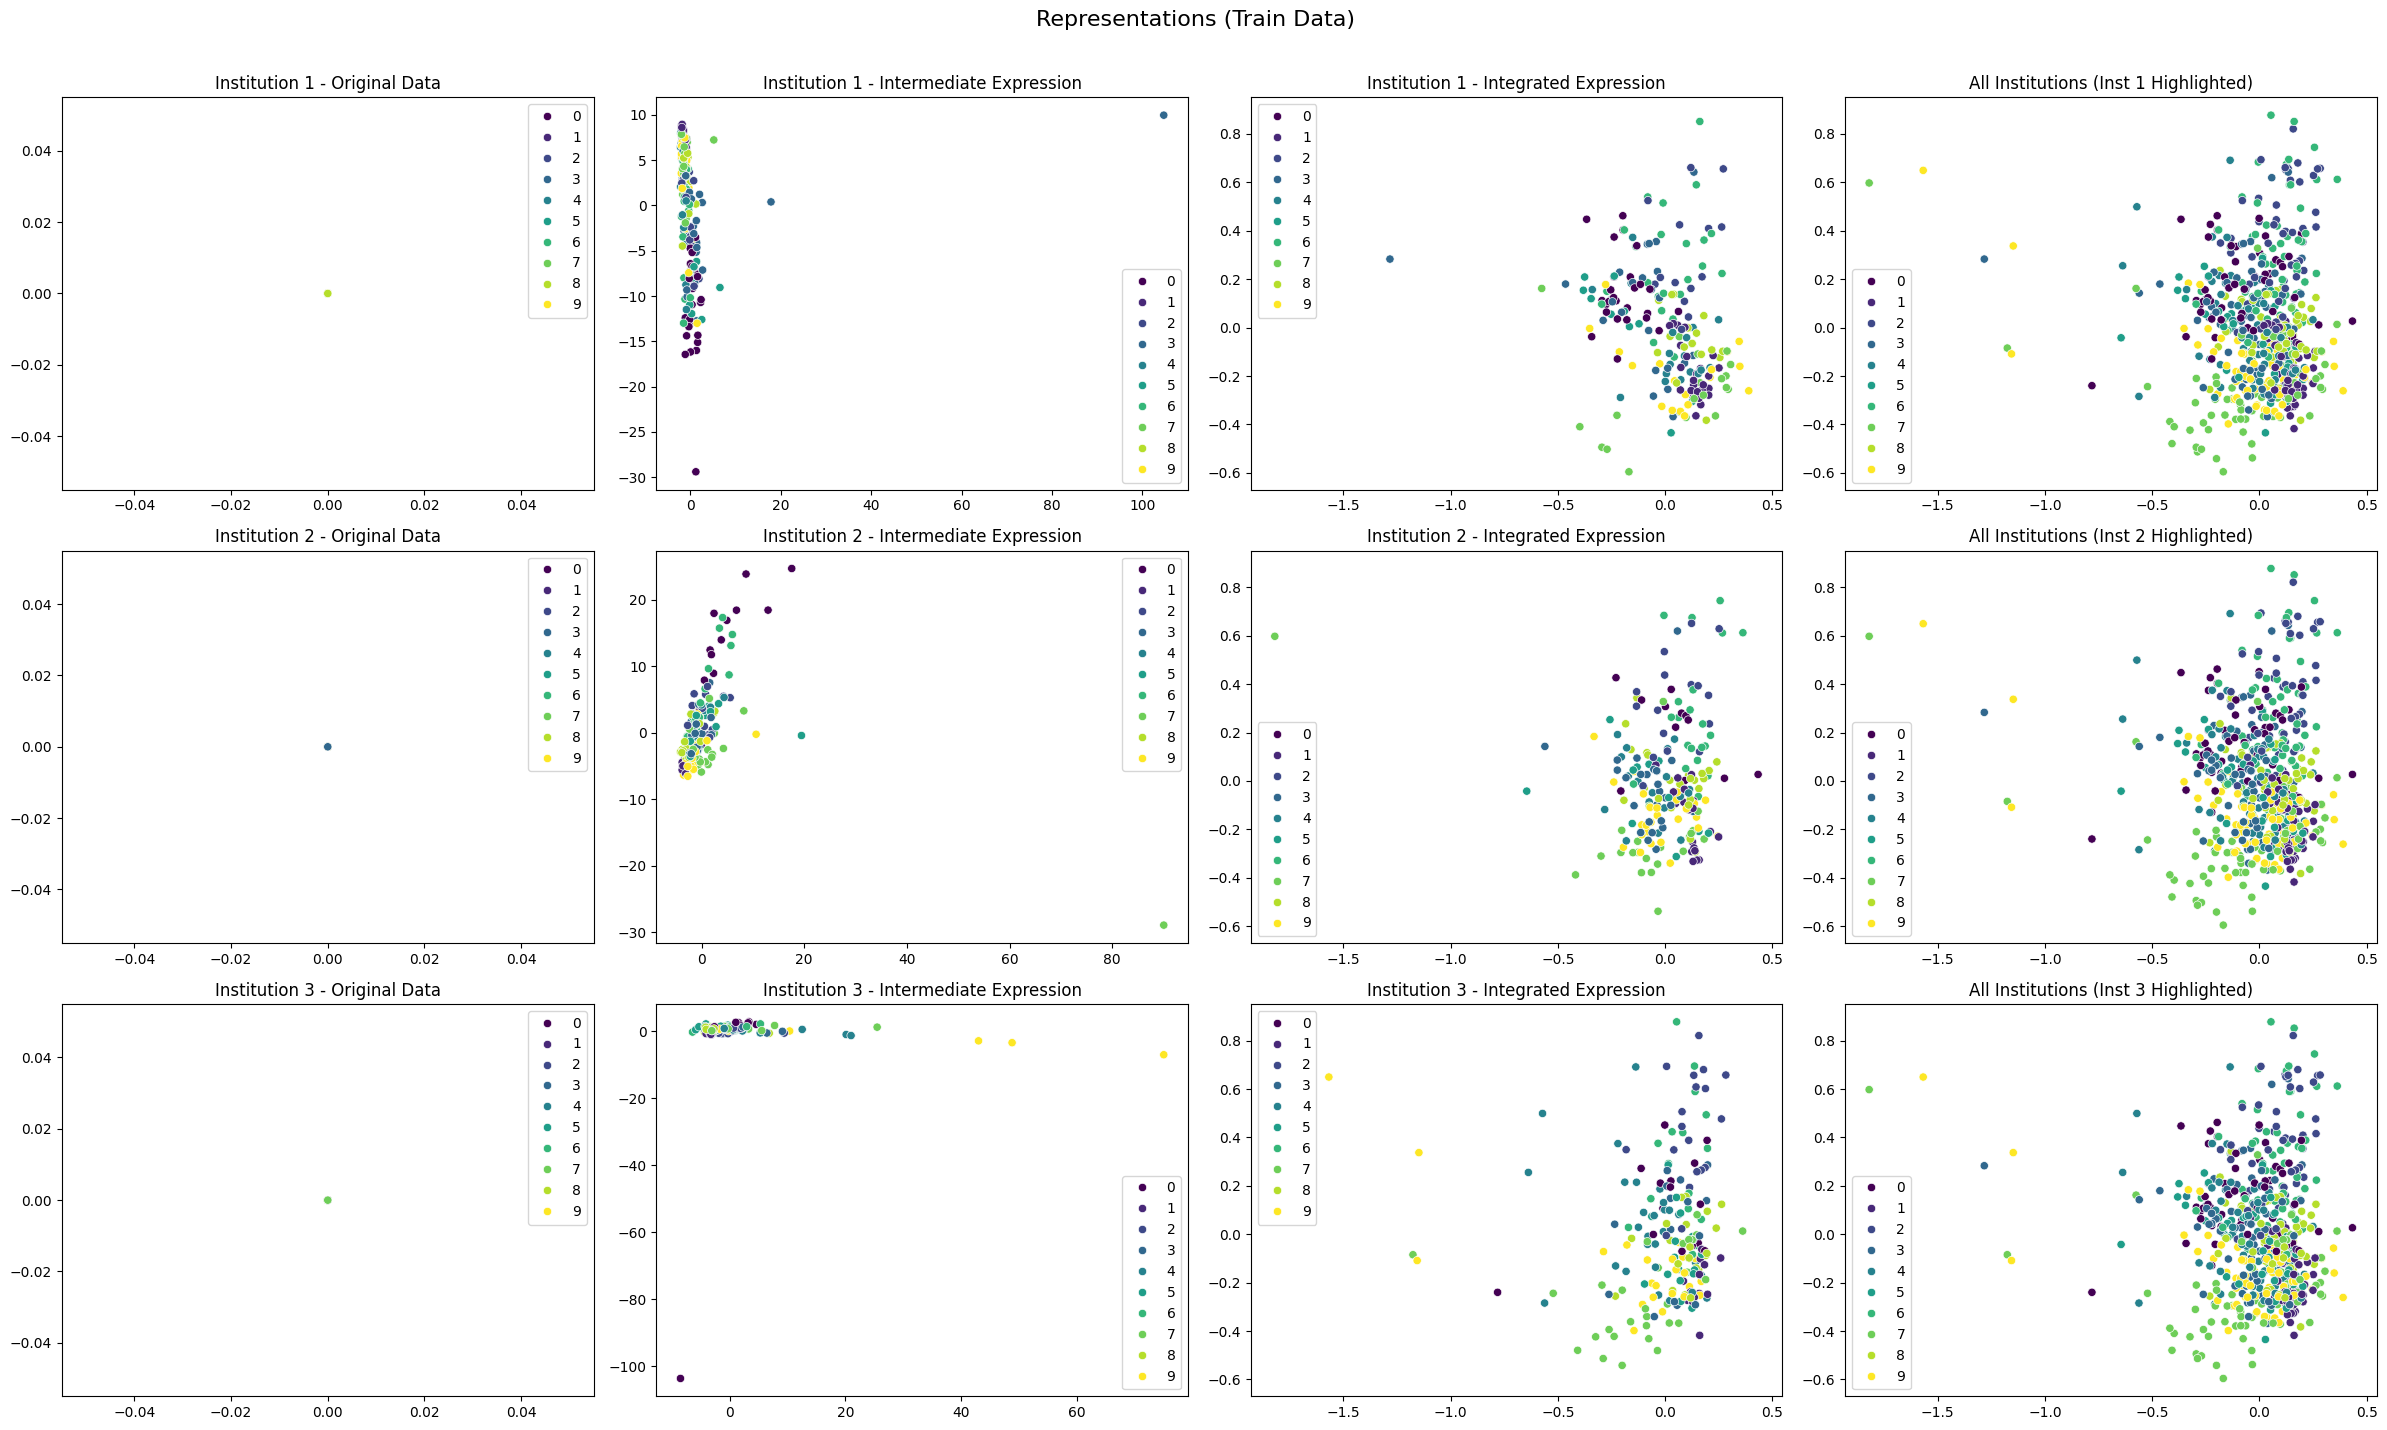

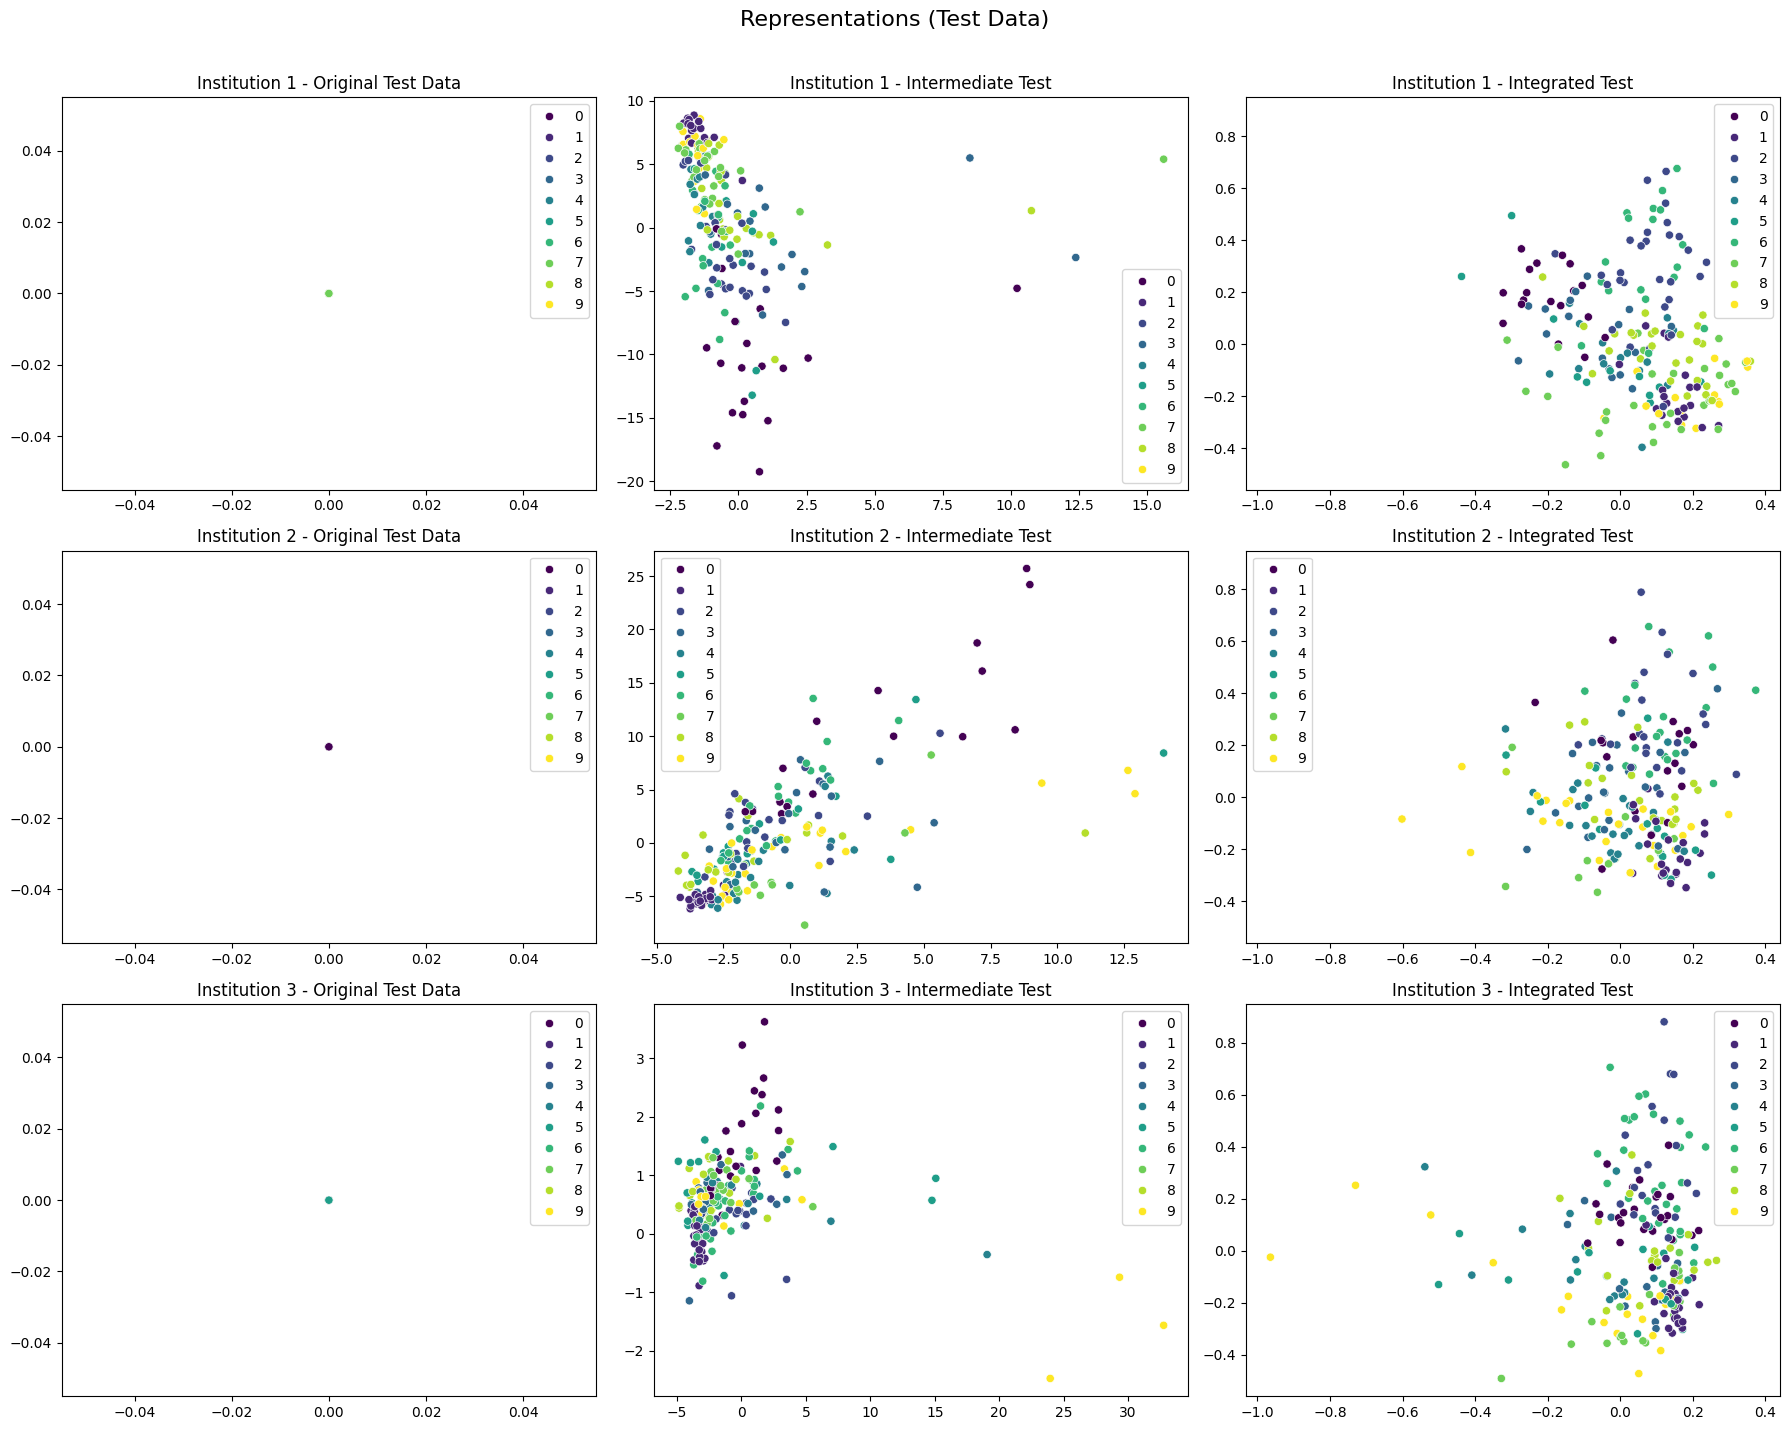

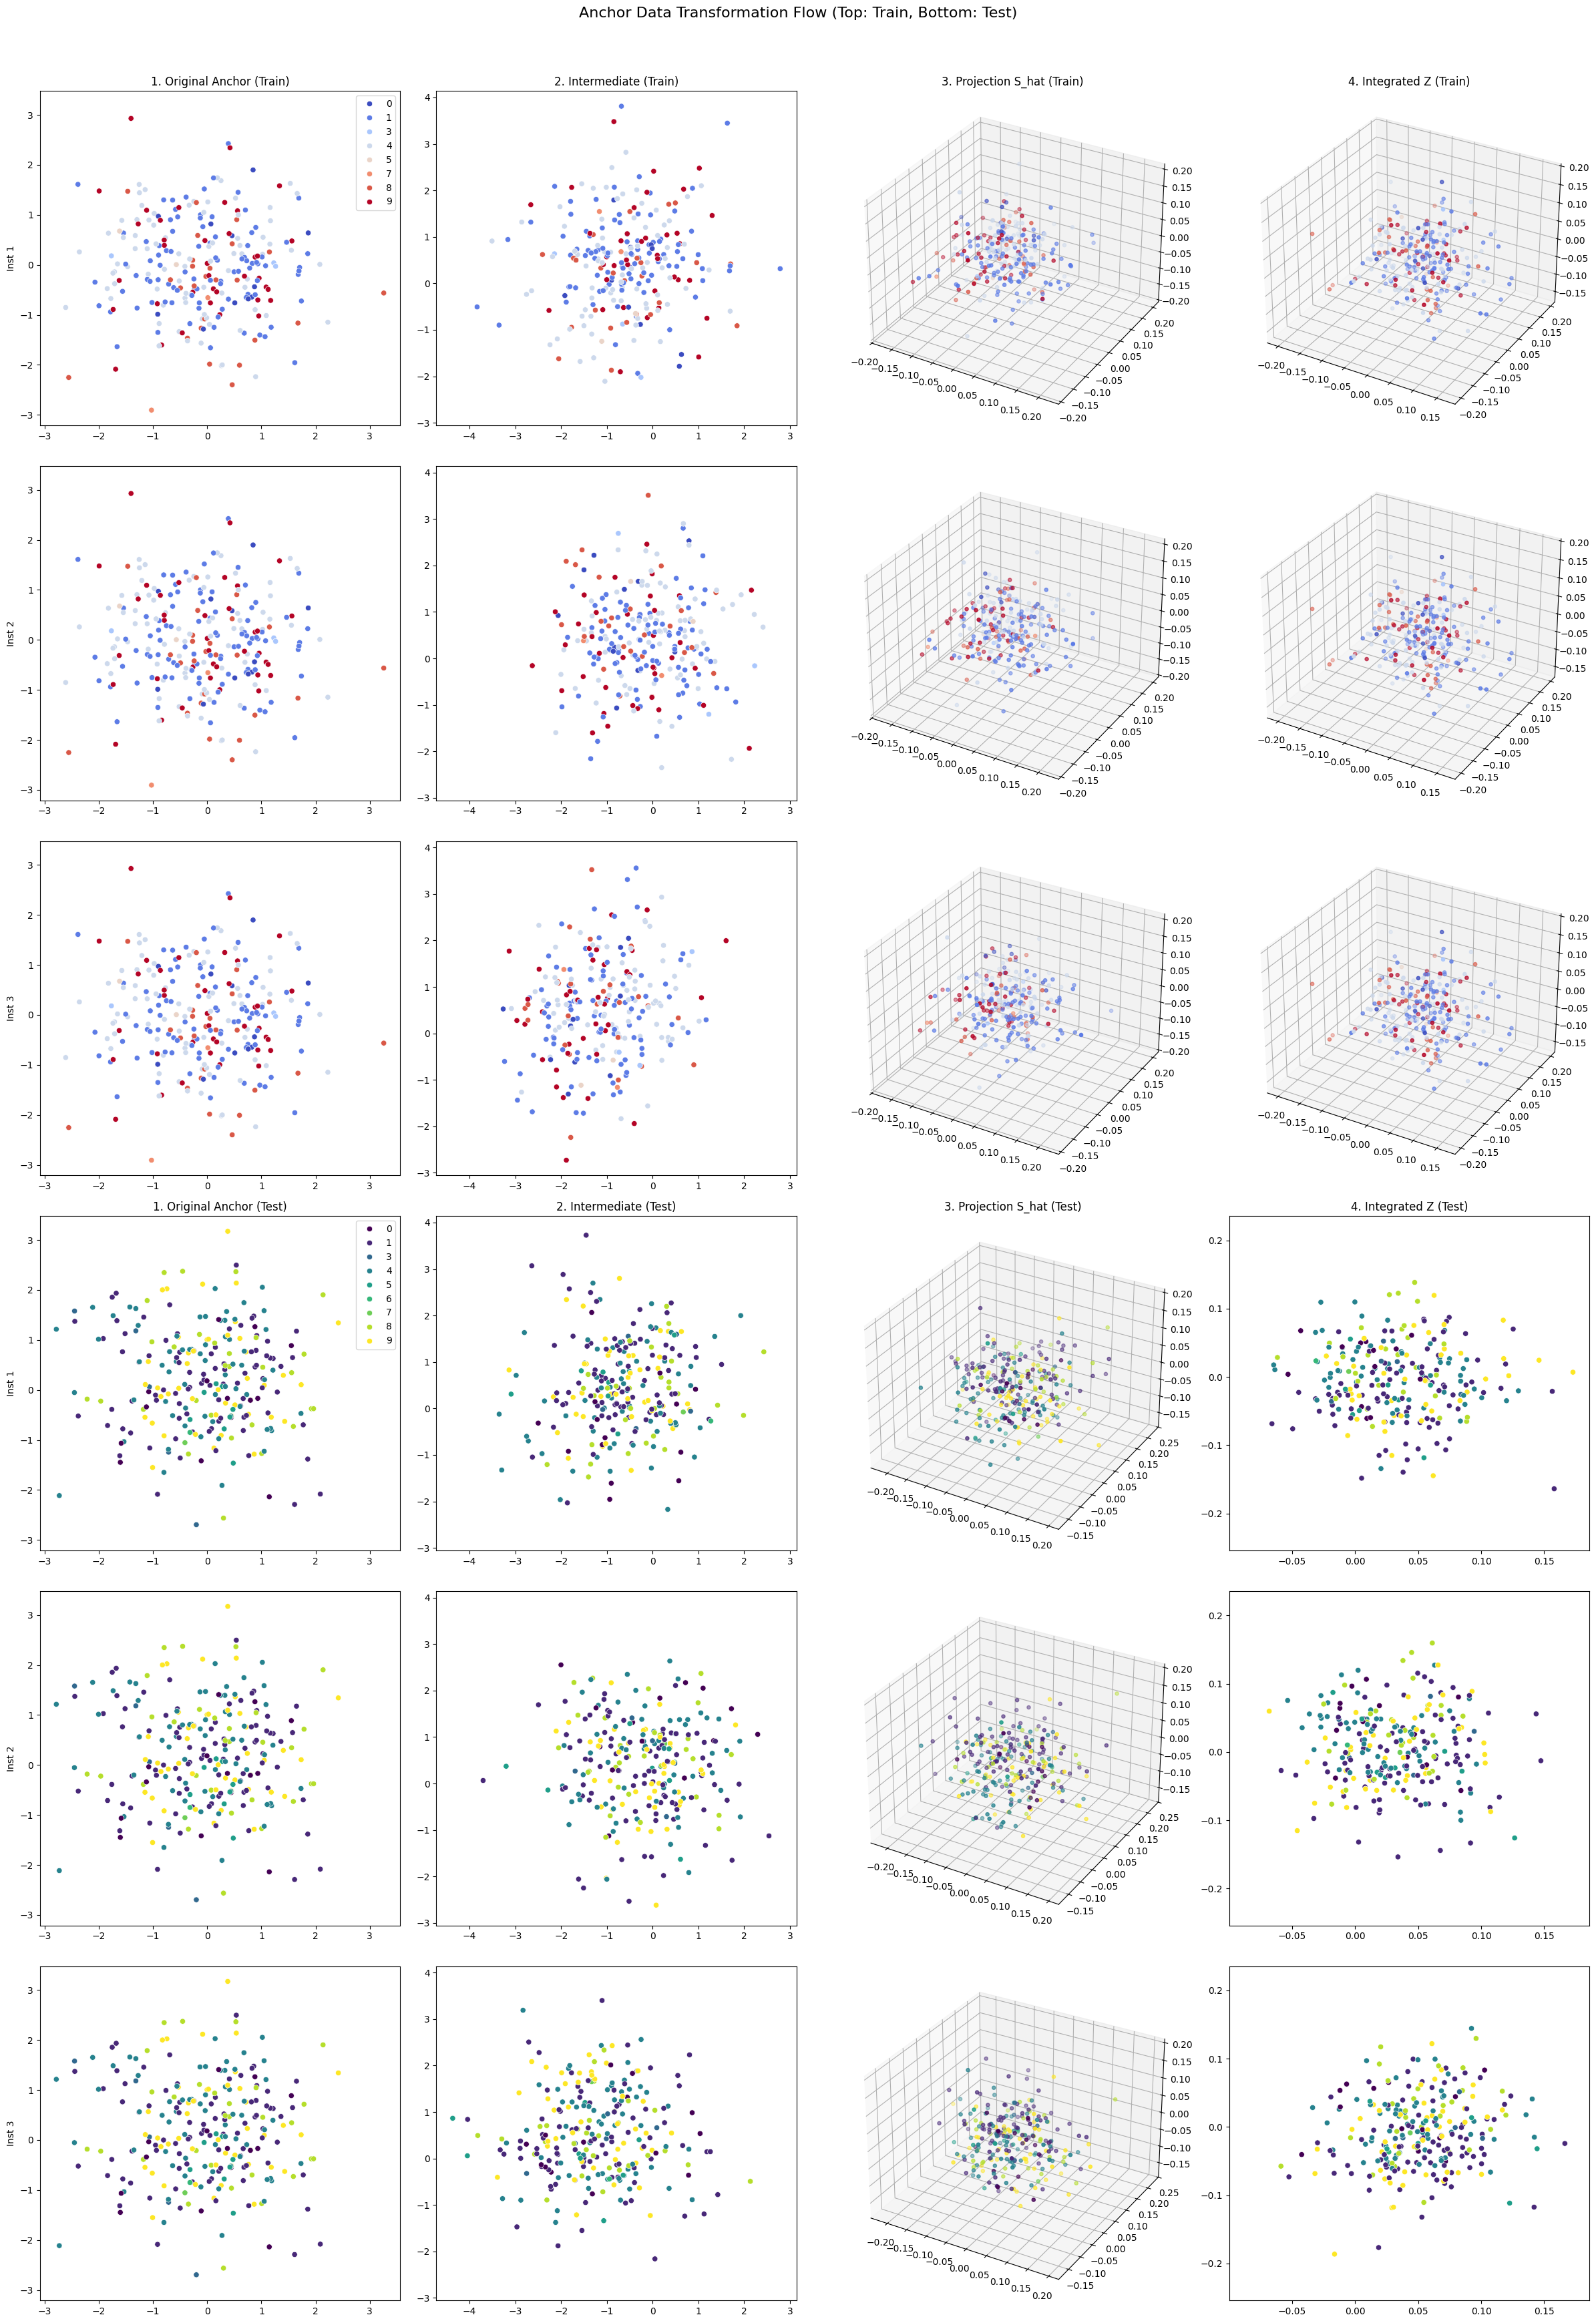

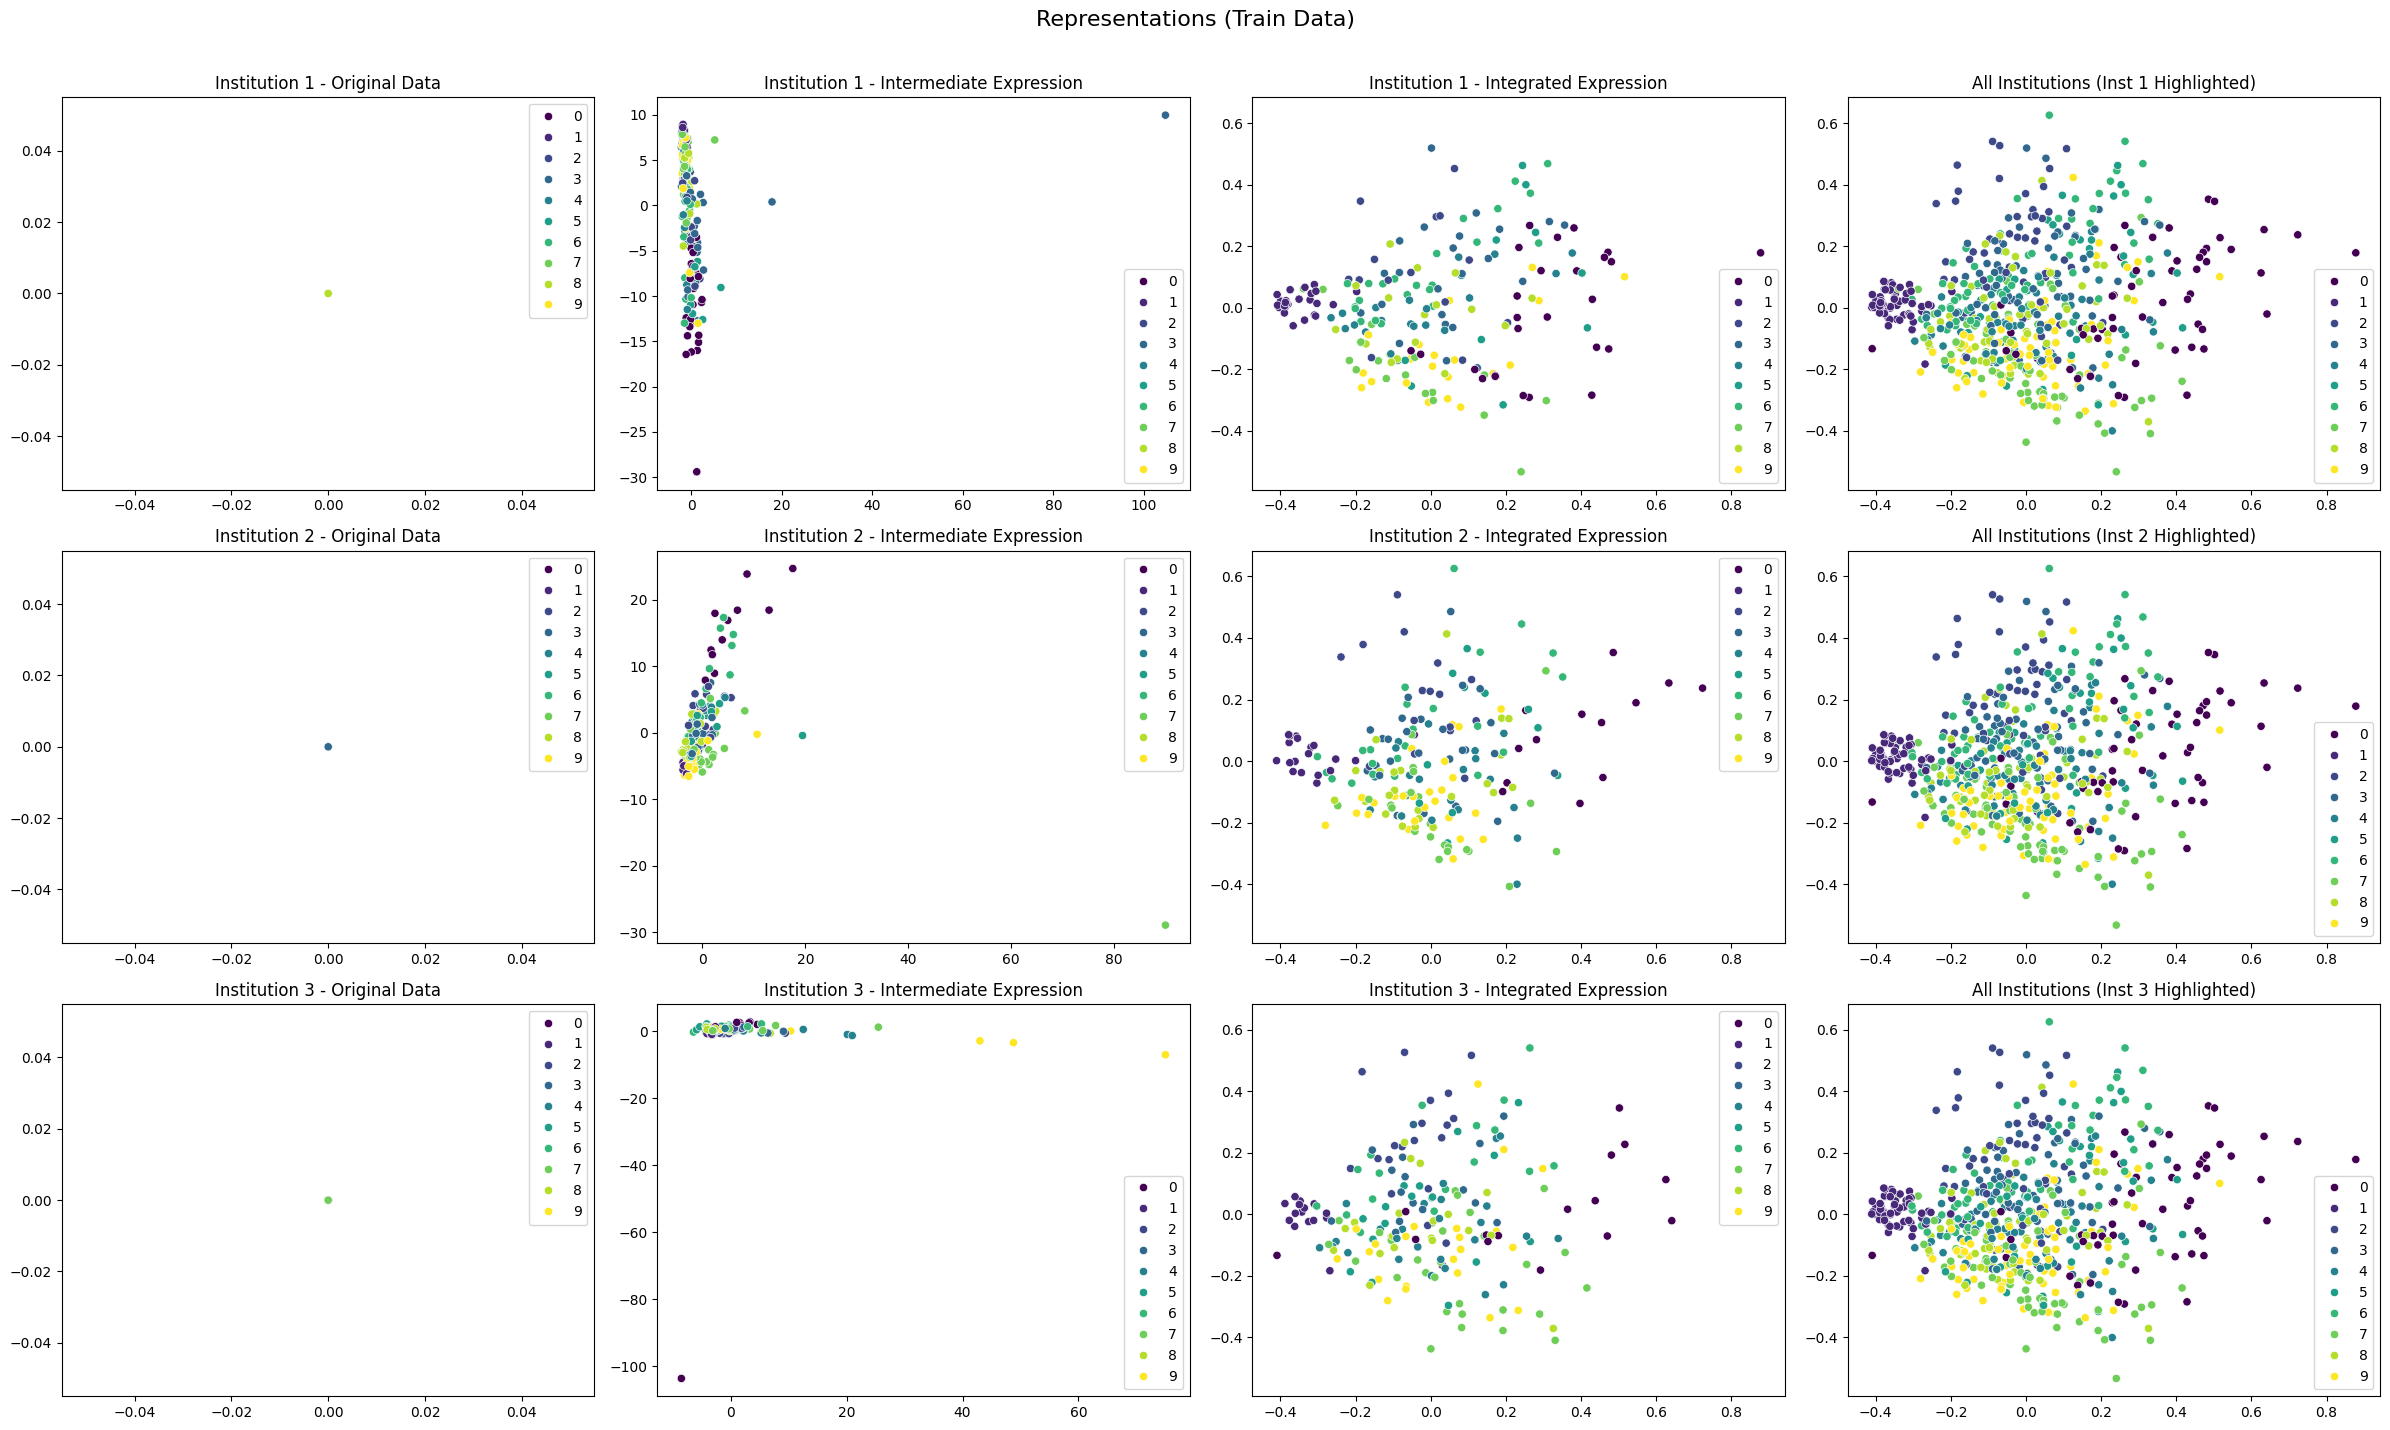

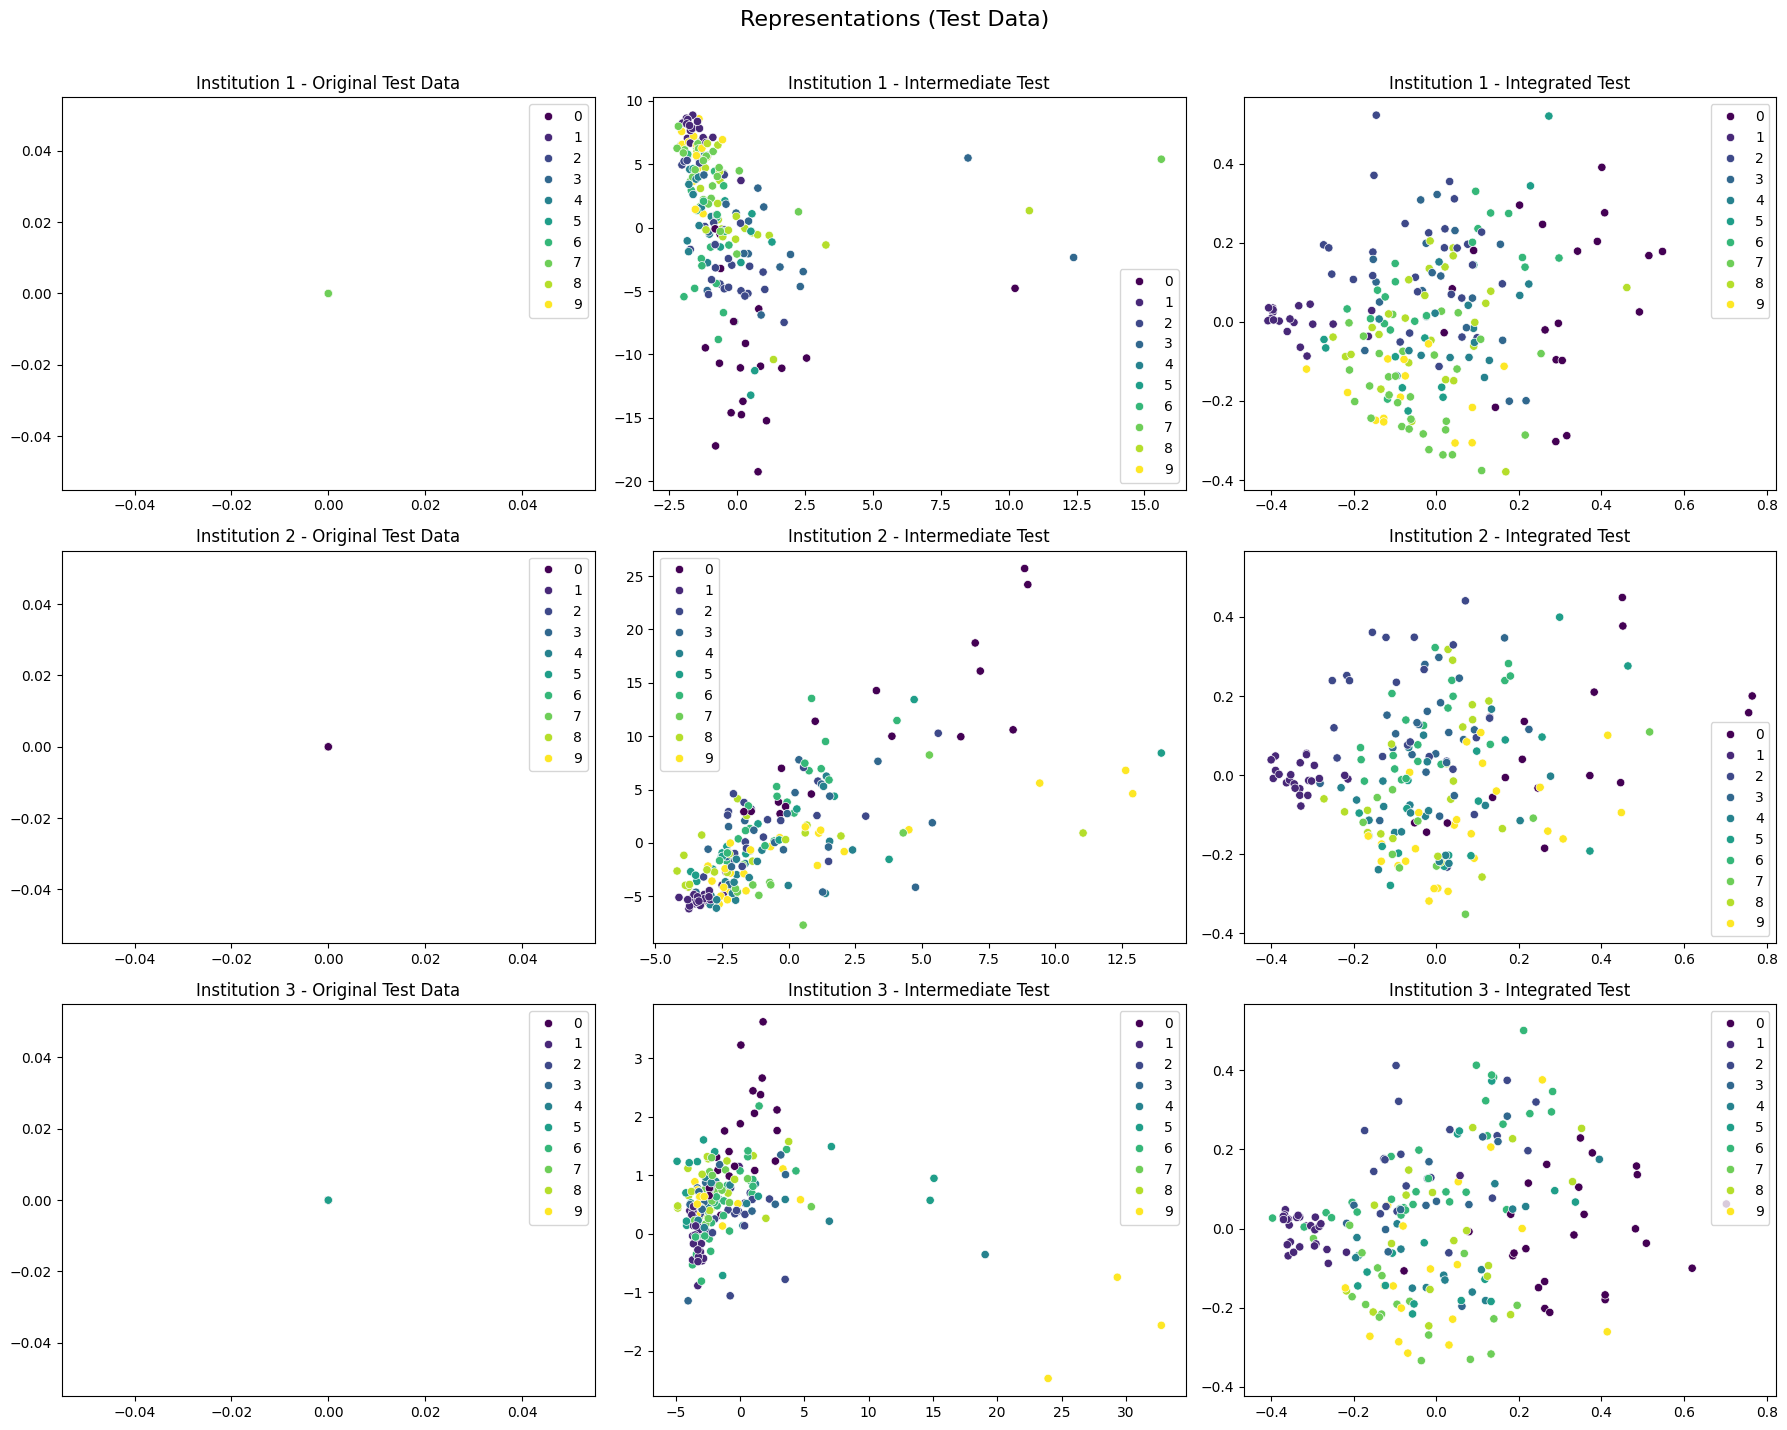

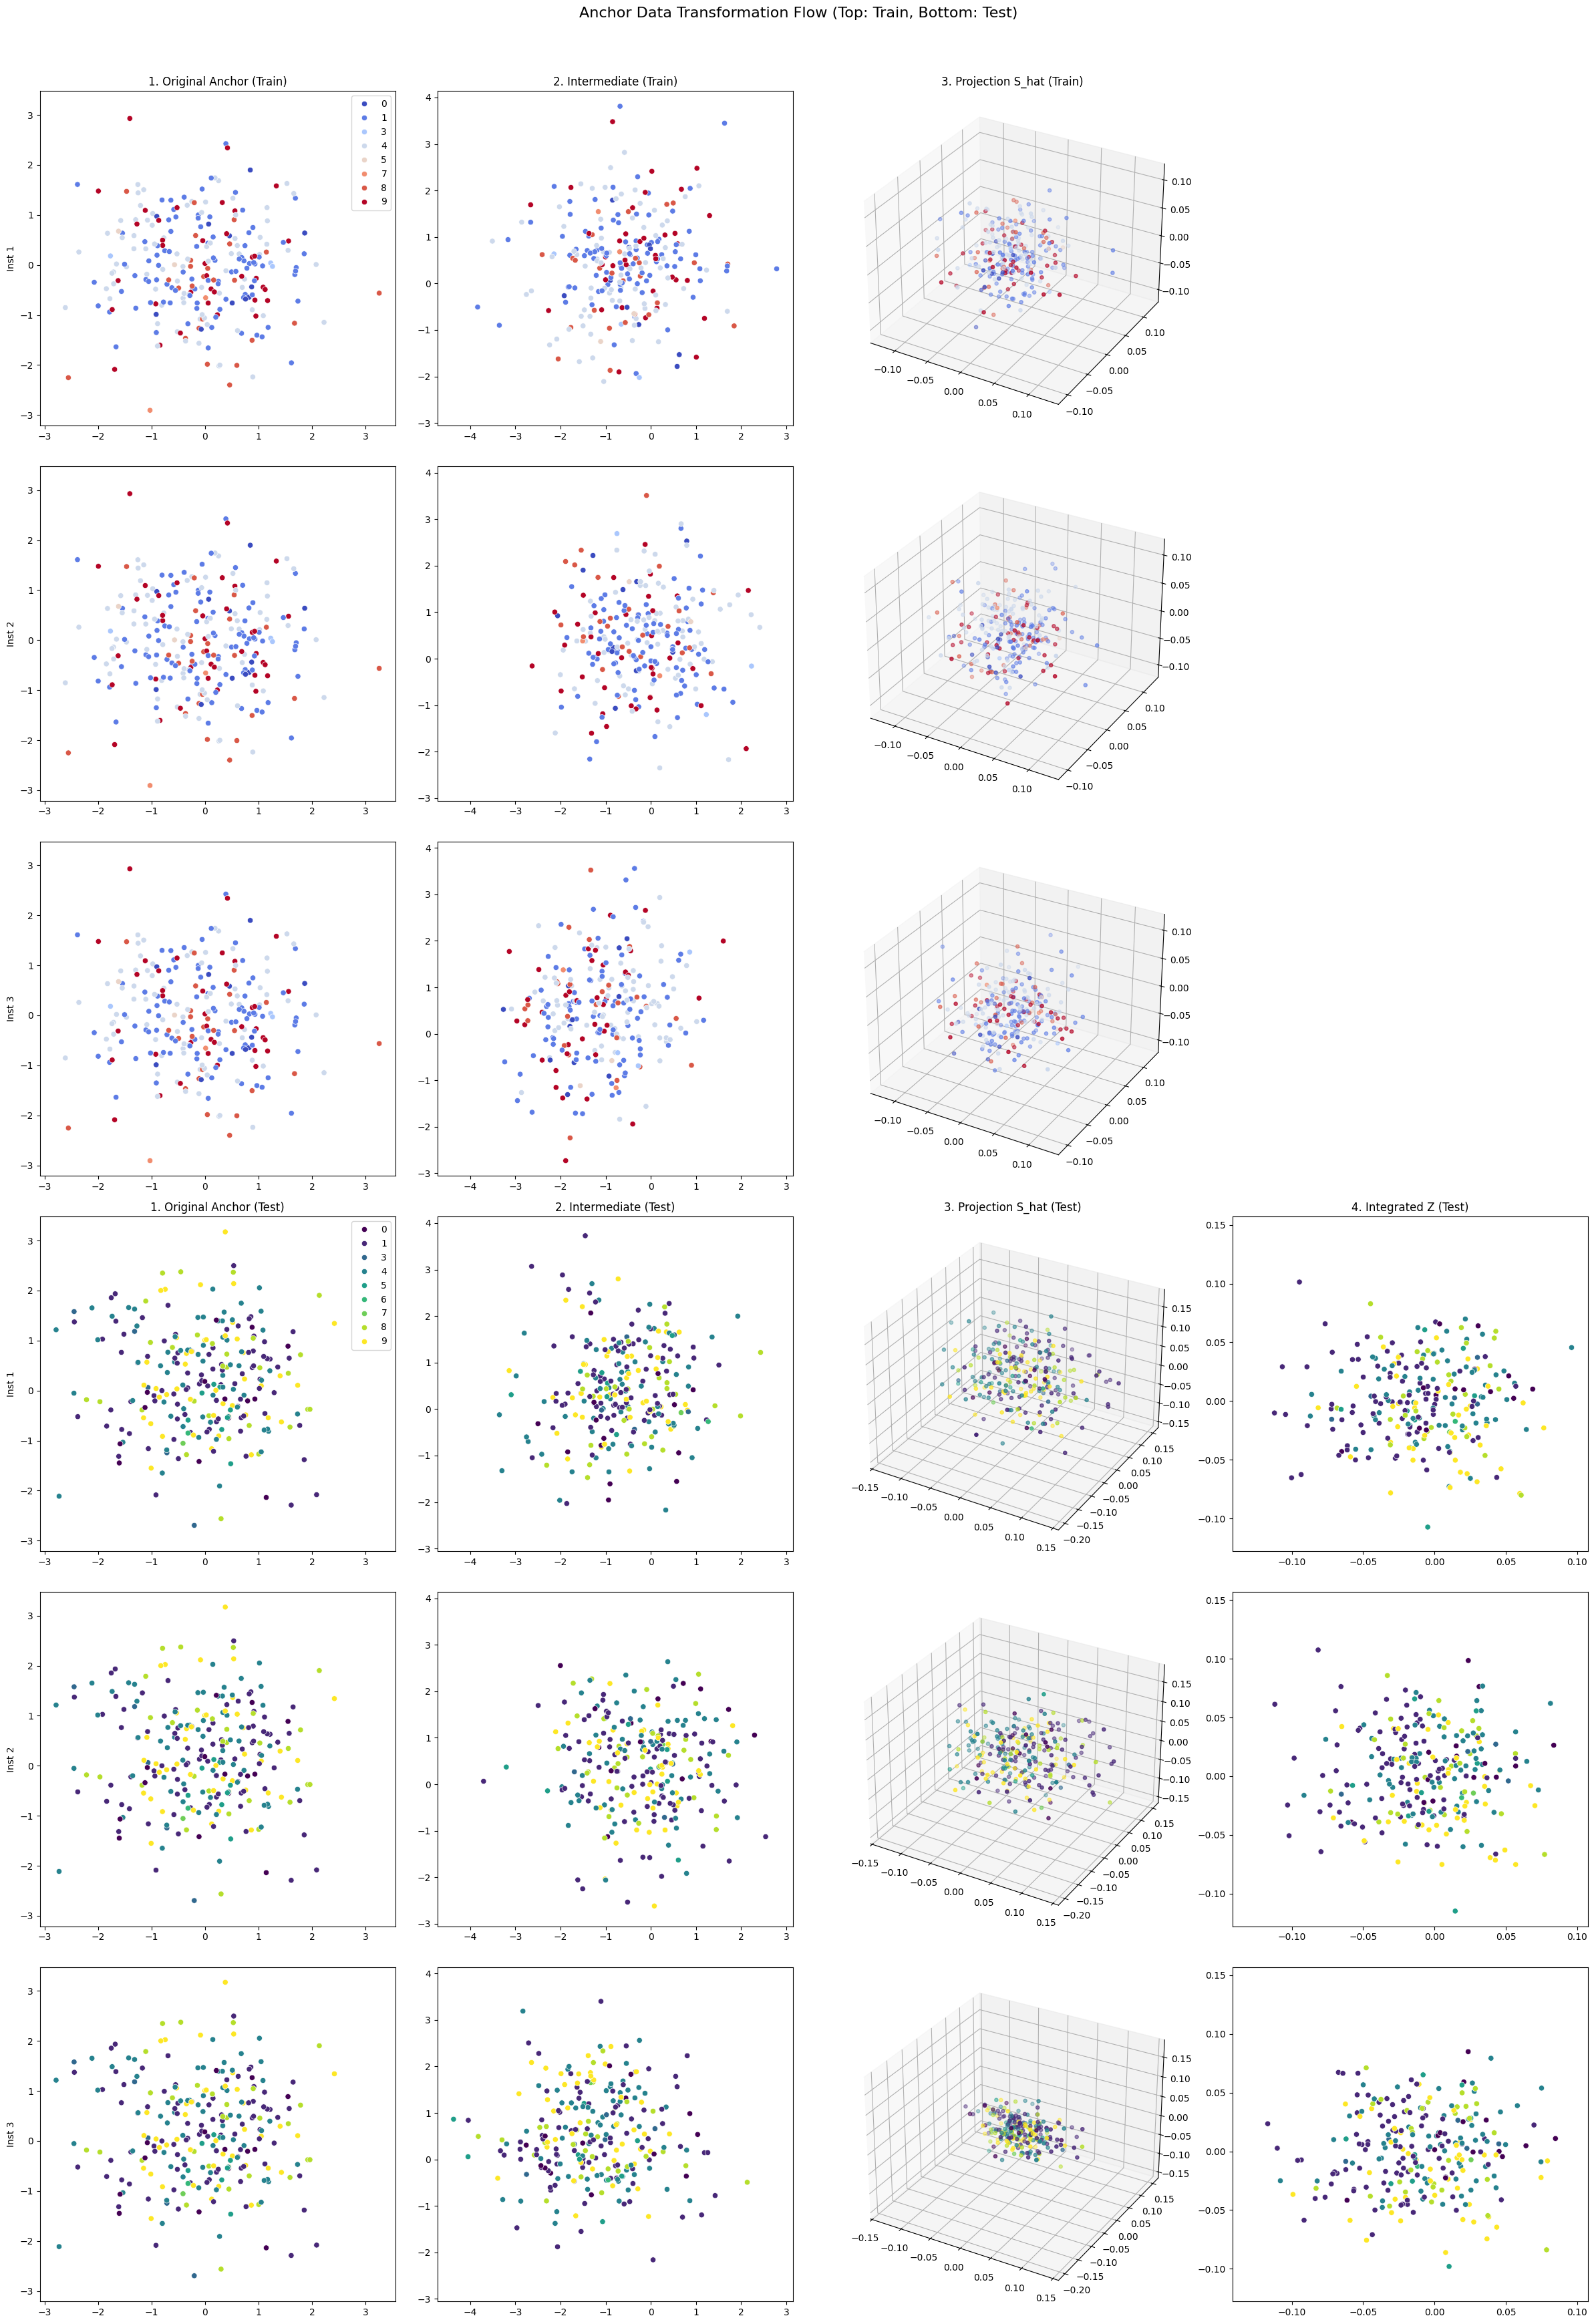

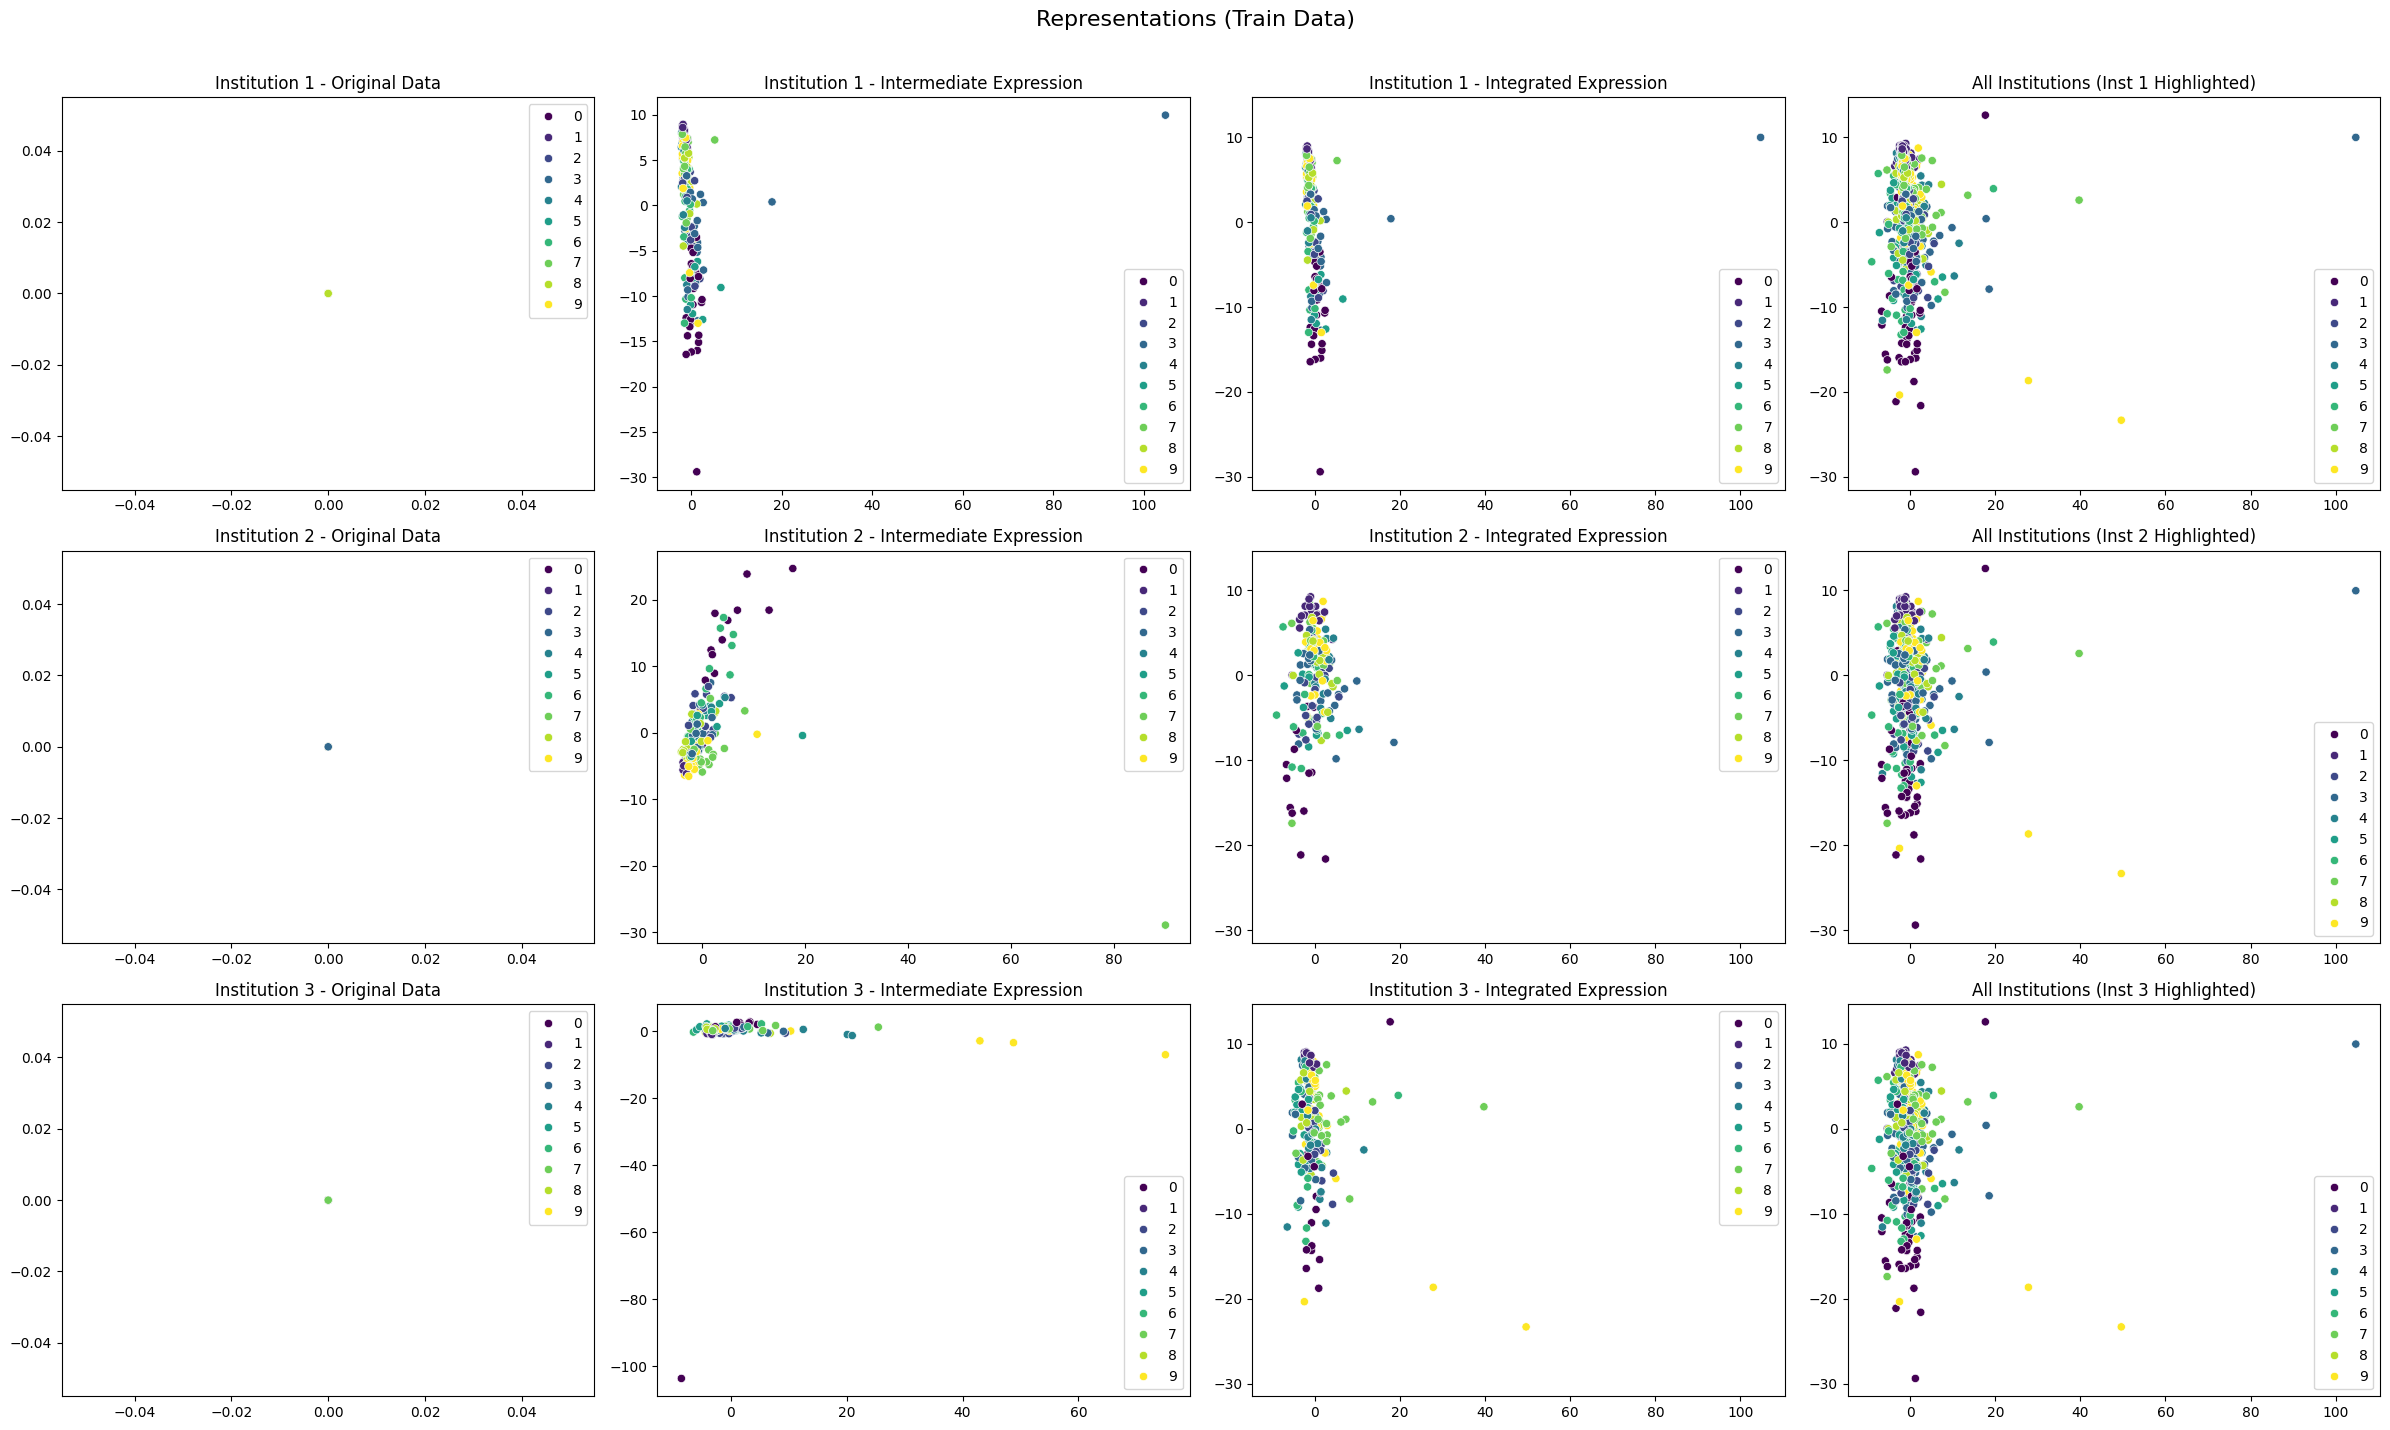

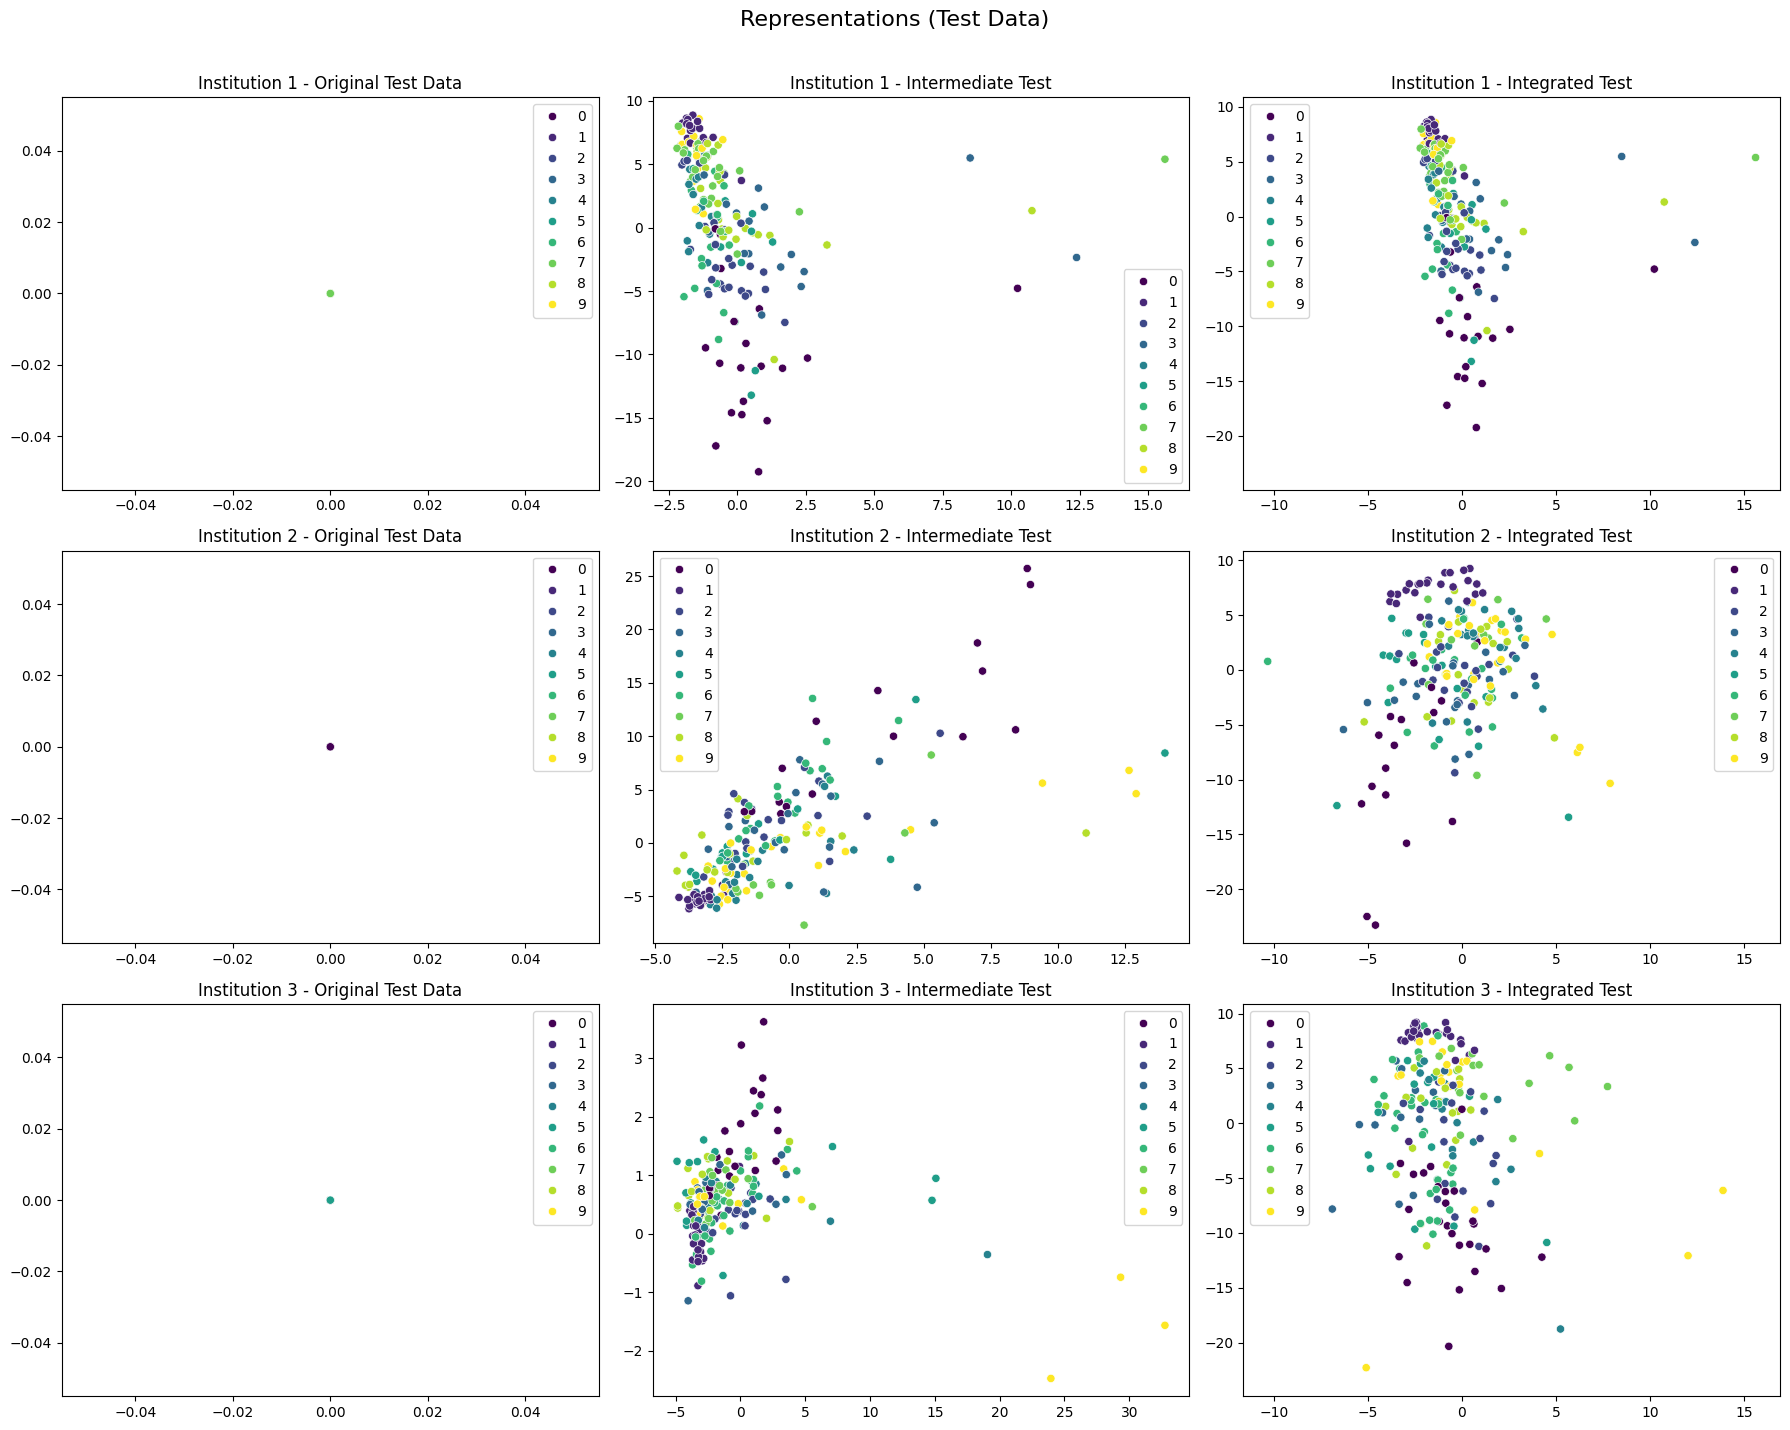

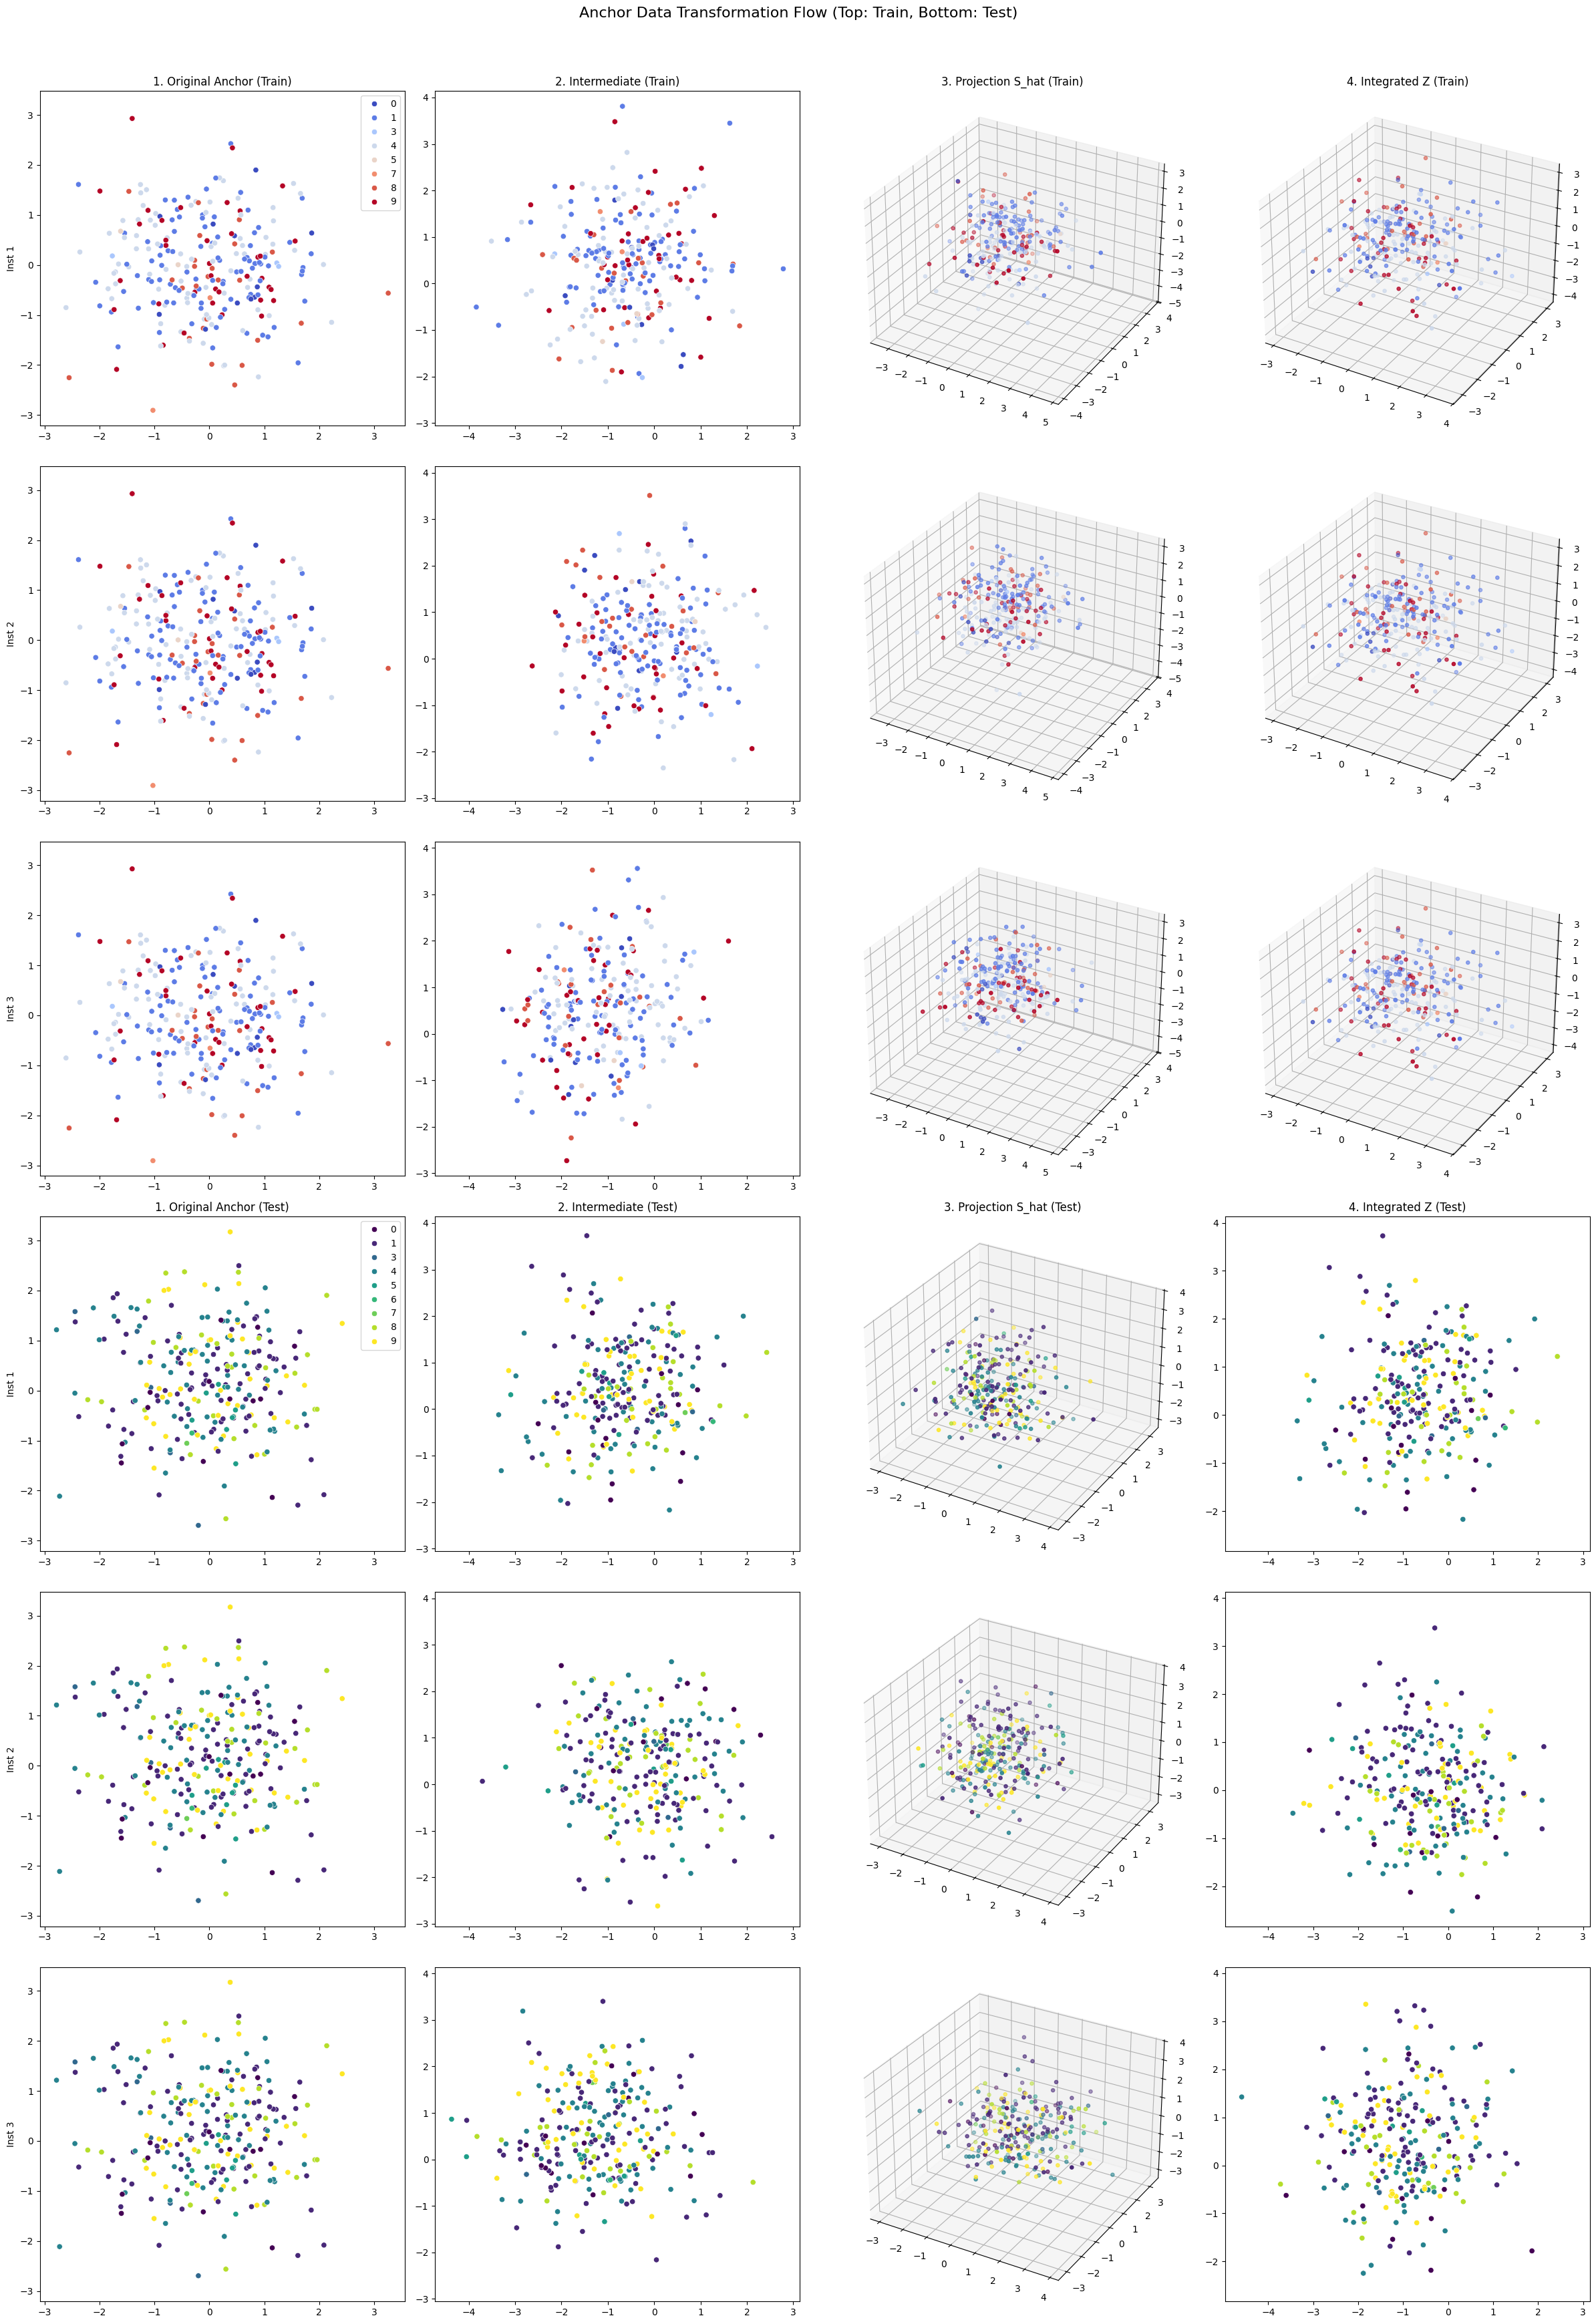

In [16]:
from src.integrated_expression import IntegratedExpressionBuilder, DataCollabVisualizer
from src.institutional_analysis import dca_analysis

G_TYPES = ['Imakura', 'GEP', 'ODC']
rows = []

for g_type in G_TYPES:
    cfg = make_config(G_type=g_type)
    integrated_builder = IntegratedExpressionBuilder(config=cfg, logger=logger)
    integrated_artifacts = integrated_builder.run(intermediate_artifacts)

    if cfg.visualize:
        viz = DataCollabVisualizer(config=cfg, artifacts=integrated_artifacts, logger=logger)
        viz.visualize_representations()

    train_embed = np.vstack(integrated_artifacts.Xs_train_integ)
    train_labels = np.hstack(integrated_artifacts.ys_train_integ)

    scores = []
    for idx in range(cfg.num_institution):
        score = dca_analysis(
            X_train_integ=train_embed,
            X_test_integ=integrated_artifacts.Xs_test_integ[idx],
            y_train_integ=train_labels,
            y_test_integ=integrated_artifacts.ys_test_integ[idx],
            config=cfg,
            logger=logger,
        )
        scores.append(score)

    scores_arr = np.array(scores, dtype=float)
    rows.append({
        'G_type': g_type,
        'mean_score': float(np.nanmean(scores_arr)),
        'per_institution': np.round(scores_arr, 4).tolist(),
    })

pd.DataFrame(rows)


## 6. まとめ

- 3 つの Builder (`InstitutionDatasetBuilder` → `IntermediateExpressionBuilder` → `IntegratedExpressionBuilder`) を直列に実行することで、ノートブックからも本番コードと同じ処理を再現できるようになりました。
- `base_config` をコピーして `G_type` を差し替えるだけで、統合法ごとの評価をすぐに比較できます。
- 他の `F_type` や `dataset` を試す場合も、`make_config()` の引数に上書きしたい値を渡すだけで一貫した実験が可能です。
